# Multi-Modal Behavioral Biometrics Detection
## App Project - Digital Forensic

**Framework**: 1 framework utama dengan beberapa sub-model/modul deteksi

| Sub-Model | Jenis Data | Arsitektur | Output |
|-----------|------------|------------|--------|
| 1 | Keystroke Dynamics | LSTM | keystroke_model.h5 |
| 2 | Scroll / Reading Behavior | RandomForest/XGBoost | scroll_model.pkl |
| 3 | Digital Signature Trajectory | CNN-LSTM | signature_model.h5 |
| 4 | Fusion / Risk Scoring | Weighted Model | fusion_model.pkl |

### Pipeline
```
Dataset Publik --> Preprocessing --> Feature Standardization --> Training --> .h5/.pkl
Dataset Mobile Pharmacy --> Same Preprocessing --> Fine-tuning / Inference
```

---
## 0. Setup & Dependencies

In [1]:
import os
import json
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

BASE_DIR = r'g:\Kegiatan\Project\Digital Forensic\App\Multi Modal'
MODEL_DIR = os.path.join(BASE_DIR, 'models')

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Model Dir  : {MODEL_DIR}')
print(f'\nModel files:')
for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f'  {f:40s} {size:8.1f} KB')

TensorFlow : 2.14.0
NumPy      : 1.26.4
Pandas     : 2.3.3
Model Dir  : g:\Kegiatan\Project\Digital Forensic\App\Multi Modal\models

Model files:
  fusion_model.json                             1.1 KB
  fusion_model.pkl                              0.7 KB
  keystroke_label_map.pkl                       0.2 KB
  keystroke_model.h5                          448.8 KB
  scroll_label_map.pkl                          0.1 KB
  scroll_model.pkl                             62.4 KB
  scroll_scaler.pkl                             0.9 KB
  signature_label_map.pkl                       0.1 KB
  signature_model.h5                          313.7 KB


---
## 1. Load All Trained Models

In [2]:
# Load sub-models
keystroke_model = load_model(os.path.join(MODEL_DIR, 'keystroke_model.h5'))
signature_model = load_model(os.path.join(MODEL_DIR, 'signature_model.h5'))
scroll_model = joblib.load(os.path.join(MODEL_DIR, 'scroll_model.pkl'))

# Load fusion config
with open(os.path.join(MODEL_DIR, 'fusion_model.json'), 'r') as f:
    fusion_config = json.load(f)

# Load scalers & label maps
scroll_scaler = joblib.load(os.path.join(MODEL_DIR, 'scroll_scaler.pkl'))
ks_label_map = joblib.load(os.path.join(MODEL_DIR, 'keystroke_label_map.pkl'))

print('=== Models Loaded ===')
print(f'Keystroke LSTM     : {keystroke_model.count_params():,} params')
print(f'Signature CNN-LSTM : {signature_model.count_params():,} params')
print(f'Scroll RF          : {scroll_model.n_estimators} estimators')
print(f'Fusion weights     : {fusion_config["weights"]}')

=== Models Loaded ===
Keystroke LSTM     : 33,303 params
Signature CNN-LSTM : 20,834 params
Scroll RF          : 100 estimators
Fusion weights     : {'keystroke': 0.2835762055734466, 'scroll': 0.35821189721327673, 'signature': 0.35821189721327673}


---
## 2. Sub-Model 1: Keystroke Dynamics (LSTM)

**Dataset**: CMU Keystroke Dynamics (publik) - dikonversi ke format pharmacy app  
**Fitur**: `timestamp_diff`, `inter_key_interval_ms`  
**Arsitektur**: LSTM(64) → Dropout → LSTM(32) → BatchNorm → Dense(64) → Dense(30)

In [3]:
# Show keystroke model architecture
keystroke_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 10, 64)            17152     
                                                                 
 dropout (Dropout)           (None, 10, 64)            0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 batch_normalization (Batch  (None, 32)                128       
 Normalization)                                                  
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 64)                2112      
                                                        

In [4]:
# Load & preview keystroke data
ks_df = pd.read_csv(os.path.join(BASE_DIR, 'converted_CMU_Keystroke.csv'), nrows=50000, dtype=str)
print(f'Dataset shape: {ks_df.shape}')
print(f'Users: {ks_df["user_id"].nunique()}')
print(f'Sessions: {ks_df["session_id"].nunique()}')
ks_df[['session_id','user_id','event_type','key_code','event_timestamp','raw_json']].head(10)

Dataset shape: (50000, 18)
Users: 12
Sessions: 4546


,session_id,user_id,event_type,key_code,event_timestamp,raw_json
0,s002-1-1,s002,keyup,period,149.10000000000002,"{""type"":""keyup"",""key_code"":""period"",""inter_key..."
1,s002-1-1,s002,keyup,t,504.7999999999999,"{""type"":""keyup"",""key_code"":""t"",""inter_key_inte..."
2,s002-1-1,s002,keyup,i,682.1999999999999,"{""type"":""keyup"",""key_code"":""i"",""inter_key_inte..."
3,s002-1-1,s002,keyup,e,928.1999999999999,"{""type"":""keyup"",""key_code"":""e"",""inter_key_inte..."
4,s002-1-1,s002,keyup,five,2089.6,"{""type"":""keyup"",""key_code"":""five"",""inter_key_i..."
5,s002-1-1,s002,keyup,Shift.r,3687.2,"{""type"":""keyup"",""key_code"":""Shift.r"",""inter_ke..."
6,s002-1-1,s002,keyup,o,4441.1,"{""type"":""keyup"",""key_code"":""o"",""inter_key_inte..."
7,s002-1-1,s002,keyup,a,4688.000000000001,"{""type"":""keyup"",""key_code"":""a"",""inter_key_inte..."
8,s002-1-1,s002,keyup,n,4794.700000000001,"{""type"":""keyup"",""key_code"":""n"",""inter_key_inte..."
9,s002-1-1,s002,keyup,l,5186.8,"{""type"":""keyup"",""key_code"":""l"",""inter_key_inte..."


Session   : s002-1-1
Actual    : s002
Predicted : s017 (confidence: 0.8160)
Match     : NO


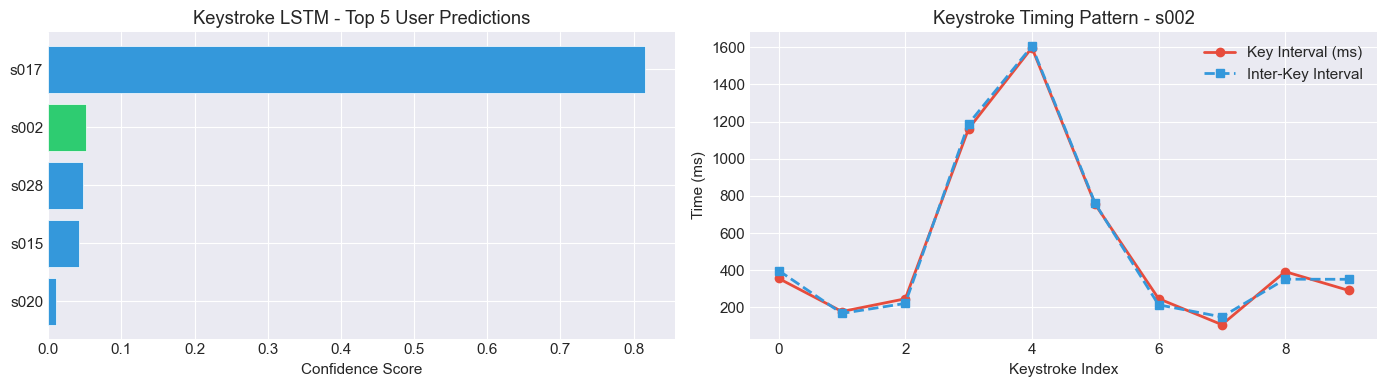

In [5]:
# Demo: predict user identity from keystroke timing
# Take a sample session
sample_sessions = ks_df.groupby('session_id').filter(lambda x: len(x) >= 10)
sample_session = sample_sessions[sample_sessions['session_id'] == sample_sessions['session_id'].unique()[0]]

# Extract features
timestamps = pd.to_numeric(sample_session['event_timestamp'], errors='coerce').fillna(0).values
iki_values = []
for raw in sample_session['raw_json']:
    try:
        rj = json.loads(str(raw))
        iki_values.append(float(rj.get('inter_key_interval_ms', 0)))
    except:
        iki_values.append(0.0)

ts_diff = np.diff(timestamps)
iki_feat = np.array(iki_values[1:])
min_len = min(len(ts_diff), len(iki_feat), 10)
features = np.column_stack([ts_diff[:min_len], iki_feat[:min_len]])

# Pad to seq_len=10
if len(features) < 10:
    features = np.vstack([features, np.zeros((10 - len(features), 2))])
features = features[:10]

# Standardize (simple z-score)
for i in range(2):
    m, s = features[:, i].mean(), features[:, i].std() + 1e-8
    features[:, i] = (features[:, i] - m) / s

# Predict
X_input = features.reshape(1, 10, 2).astype(np.float32)
pred = keystroke_model.predict(X_input, verbose=0)
pred_user_idx = np.argmax(pred[0])
confidence = pred[0][pred_user_idx]

# Reverse label map
idx_to_user = {v: k for k, v in ks_label_map.items()}
pred_user = idx_to_user.get(pred_user_idx, f'User-{pred_user_idx}')
actual_user = sample_session['user_id'].iloc[0]

print(f'Session   : {sample_session["session_id"].iloc[0]}')
print(f'Actual    : {actual_user}')
print(f'Predicted : {pred_user} (confidence: {confidence:.4f})')
print(f'Match     : {"YES" if pred_user == actual_user else "NO"}')

# Plot top-5 predictions
top5_idx = np.argsort(pred[0])[-5:][::-1]
top5_users = [idx_to_user.get(i, f'User-{i}') for i in top5_idx]
top5_conf = pred[0][top5_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
colors = ['#2ecc71' if u == actual_user else '#3498db' for u in top5_users]
axes[0].barh(top5_users, top5_conf, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Confidence Score')
axes[0].set_title('Keystroke LSTM - Top 5 User Predictions')
axes[0].invert_yaxis()

# Timing pattern
axes[1].plot(ts_diff[:10], 'o-', color='#e74c3c', label='Key Interval (ms)', linewidth=2)
axes[1].plot(np.array(iki_values[1:11]), 's--', color='#3498db', label='Inter-Key Interval', linewidth=2)
axes[1].set_xlabel('Keystroke Index')
axes[1].set_ylabel('Time (ms)')
axes[1].set_title(f'Keystroke Timing Pattern - {actual_user}')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Sub-Model 2: Scroll / Reading Behavior (RandomForest)

**Dataset**: Mobile Pharmacy App (behavior-sessions)  
**Fitur**: velocity (avg/max/min/std), scroll distance, direction changes, viewport progress  
**Arsitektur**: RandomForest (100 estimators)

In [6]:
# Load pharmacy behavior data
pharmacy_csv = os.path.join(BASE_DIR, 'behavior-sessions-1778908212345.csv')
pharm_df = pd.read_csv(pharmacy_csv, dtype=str)

print(f'Total rows: {len(pharm_df)}')
print(f'Sessions: {pharm_df["session_id"].nunique()}')
print(f'Users: {pharm_df["user_id"].nunique()}')
print(f'\nEvent types:')
print(pharm_df['event_type'].value_counts())
print(f'\nScenario types:')
print(pharm_df['scenario_type'].value_counts())

Total rows: 66
Sessions: 5
Users: 2

Event types:
event_type
scroll              58
signature_stroke     7
keyup                1
Name: count, dtype: int64

Scenario types:
scenario_type
scroll       58
signature     7
search        1
Name: count, dtype: int64


Sessions with scroll data: 5


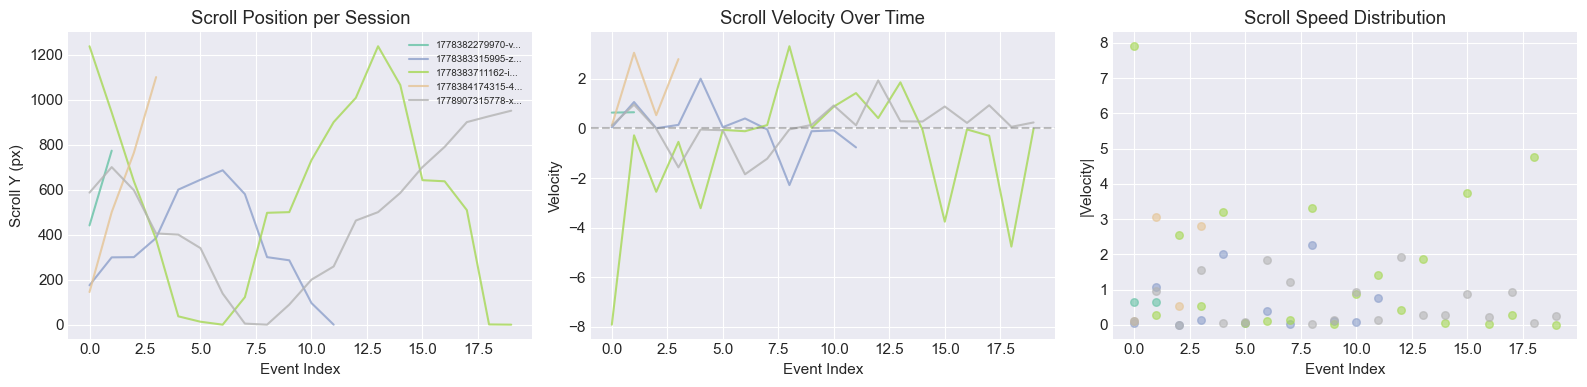

In [7]:
# Extract scroll features from all sessions
scroll_df = pharm_df[pharm_df['event_type'] == 'scroll'].copy()

# Parse velocity from raw_json
velocities_all = []
positions_all = []
sessions_data = {}

for session_id, group in scroll_df.groupby('session_id'):
    vels = []
    pos = []
    times = []
    for _, row in group.iterrows():
        try:
            rj = json.loads(row['raw_json'].replace('""', '"'))
            vels.append(float(rj.get('velocity', 0)))
            pos.append(float(rj.get('scroll_y', 0)))
            times.append(float(row['event_timestamp']))
        except:
            pass
    if len(vels) > 1:
        sessions_data[session_id] = {'velocity': vels, 'position': pos, 'time': times}

print(f'Sessions with scroll data: {len(sessions_data)}')

# Visualize scroll patterns
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = plt.cm.Set2(np.linspace(0, 1, len(sessions_data)))
for i, (sid, data) in enumerate(sessions_data.items()):
    label = sid[:15] + '...'
    axes[0].plot(data['position'], color=colors[i], linewidth=1.5, alpha=0.8, label=label)
    axes[1].plot(data['velocity'], color=colors[i], linewidth=1.5, alpha=0.8)
    axes[2].scatter(range(len(data['velocity'])), np.abs(data['velocity']), 
                    color=colors[i], alpha=0.6, s=30)

axes[0].set_title('Scroll Position per Session')
axes[0].set_xlabel('Event Index')
axes[0].set_ylabel('Scroll Y (px)')

axes[1].set_title('Scroll Velocity Over Time')
axes[1].set_xlabel('Event Index')
axes[1].set_ylabel('Velocity')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

axes[2].set_title('Scroll Speed Distribution')
axes[2].set_xlabel('Event Index')
axes[2].set_ylabel('|Velocity|')

axes[0].legend(fontsize=7, loc='best')
plt.tight_layout()
plt.show()

In [8]:
# Feature extraction demo for scroll model
def extract_scroll_features(session_data):
    v = np.array(session_data['velocity'])
    p = np.array(session_data['position'])
    t = np.array(session_data['time'])
    
    scroll_diffs = np.diff(p)
    dir_changes = np.sum(np.abs(np.diff(np.sign(scroll_diffs))) > 0) if len(scroll_diffs) > 1 else 0
    time_diffs = np.diff(t)
    
    return {
        'avg_velocity': np.mean(np.abs(v)),
        'max_velocity': np.max(np.abs(v)),
        'min_velocity': np.min(np.abs(v)),
        'std_velocity': np.std(v),
        'total_scroll_distance': np.sum(np.abs(np.diff(p))),
        'n_scroll_events': len(v),
        'n_direction_changes': dir_changes,
        'avg_time_between_scrolls': np.mean(time_diffs) if len(time_diffs) > 0 else 0,
        'viewport_progress_max': 1.0,
        'scroll_range': np.max(p) - np.min(p),
    }

# Extract & predict for each session
print(f'{"Session":>20s}  {"Features":>10s}  {"Prediction":>12s}  {"Confidence":>10s}')
print('-' * 60)

for sid, data in sessions_data.items():
    feats = extract_scroll_features(data)
    X = np.array(list(feats.values())).reshape(1, -1).astype(np.float32)
    X_scaled = scroll_scaler.transform(X)
    
    pred = scroll_model.predict(X_scaled)[0]
    proba = scroll_model.predict_proba(X_scaled)[0]
    conf = max(proba)
    
    print(f'{sid[:20]:>20s}  {len(feats):>10d}  {"User-" + str(pred):>12s}  {conf:>10.4f}')

             Session    Features    Prediction  Confidence
------------------------------------------------------------
1778382279970-vm141v          10        User-1      0.9000
1778383315995-ze8d2l          10        User-1      0.8000
1778383711162-ib6is2          10        User-1      0.8500
1778384174315-4ksawb          10        User-1      0.9700
1778907315778-xm39k7          10        User-0      0.6100


---
## 4. Sub-Model 3: Digital Signature Trajectory (CNN-LSTM)

**Dataset**: Mobile Pharmacy App (signature_stroke events)  
**Fitur**: x, y (normalized), pressure, dx/dt, dy/dt, velocity, stroke_start  
**Arsitektur**: Conv1D(32) → Conv1D(64) → LSTM(32) → Dense(32) → Dense(2)

In [9]:
# Show signature model architecture
signature_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_1 (Conv1D)           (None, 80, 32)            704       
                                                                 
 batch_normalization_1 (Bat  (None, 80, 32)            128       
 chNormalization)                                                
                                                                 
 max_pooling1d (MaxPooling1  (None, 40, 32)            0         
 D)                                                              
                                                                 
 conv1d_2 (Conv1D)           (None, 40, 64)            6208      
                                                                 
 batch_normalization_2 (Bat  (None, 40, 64)            256       
 chNormalization)                                                
                                                      

Signature stroke events: 7
Sessions with signatures: 2


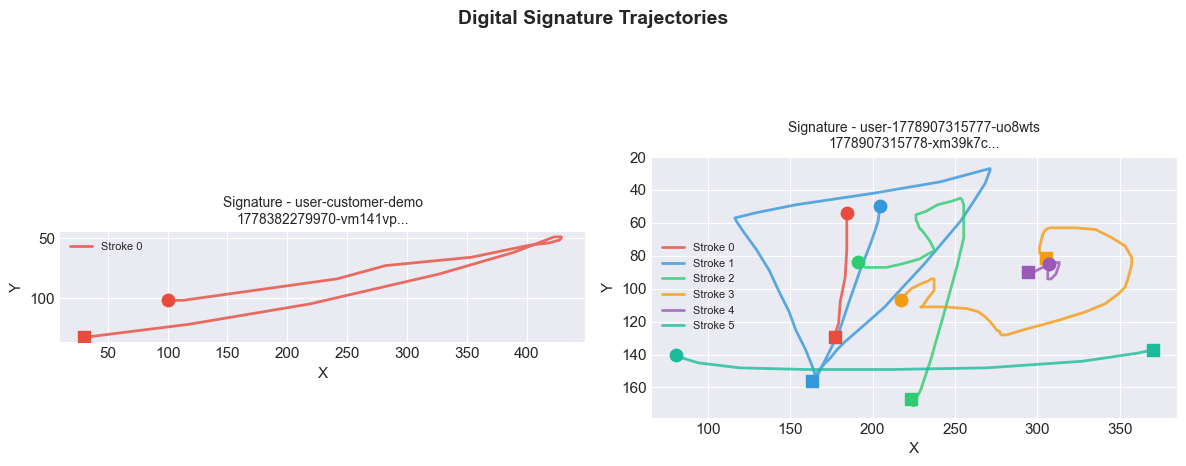

In [10]:
# Extract and visualize signature data
sig_df = pharm_df[pharm_df['event_type'] == 'signature_stroke'].copy()
print(f'Signature stroke events: {len(sig_df)}')

# Parse signature points per session
sig_sessions = {}
for session_id, group in sig_df.groupby('session_id'):
    all_strokes = []
    for _, row in group.iterrows():
        try:
            raw = row['raw_json'].replace('""', '"')
            rj = json.loads(raw)
            points = rj.get('points', [])
            stroke = []
            for p in points:
                stroke.append({
                    'x': float(p['x']), 'y': float(p['y']),
                    'pressure': float(p.get('pressure', 0.5)),
                    'timestamp': float(p['timestamp']),
                    'is_stroke_start': p.get('is_stroke_start', False)
                })
            if stroke:
                all_strokes.append(stroke)
        except:
            pass
    if all_strokes:
        sig_sessions[session_id] = all_strokes

print(f'Sessions with signatures: {len(sig_sessions)}')

# Plot each signature
n_sigs = len(sig_sessions)
fig, axes = plt.subplots(1, n_sigs, figsize=(6 * n_sigs, 5))
if n_sigs == 1:
    axes = [axes]

stroke_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for ax_idx, (sid, strokes) in enumerate(sig_sessions.items()):
    ax = axes[ax_idx]
    user_id = sig_df[sig_df['session_id'] == sid]['user_id'].iloc[0]
    
    for s_idx, stroke in enumerate(strokes):
        xs = [p['x'] for p in stroke]
        ys = [p['y'] for p in stroke]
        color = stroke_colors[s_idx % len(stroke_colors)]
        
        ax.plot(xs, ys, '-', color=color, linewidth=2, alpha=0.8, label=f'Stroke {s_idx}')
        ax.scatter(xs[0], ys[0], color=color, s=80, zorder=5, marker='o')  # start
        ax.scatter(xs[-1], ys[-1], color=color, s=80, zorder=5, marker='s')  # end
    
    ax.set_title(f'Signature - {user_id}\n{sid[:25]}...', fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.invert_yaxis()  # screen coordinates
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

plt.suptitle('Digital Signature Trajectories', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

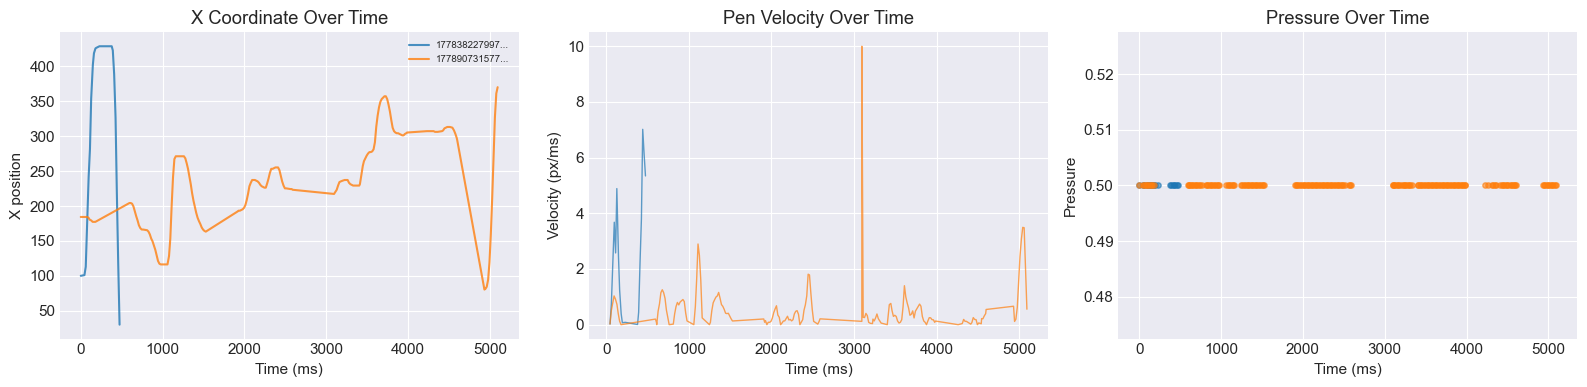

In [11]:
# Signature feature analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for sid, strokes in sig_sessions.items():
    # Flatten all points
    all_pts = [p for stroke in strokes for p in stroke]
    times = [p['timestamp'] for p in all_pts]
    xs = [p['x'] for p in all_pts]
    ys = [p['y'] for p in all_pts]
    pressures = [p['pressure'] for p in all_pts]
    
    t_rel = np.array(times) - times[0]
    
    # Velocity
    dx = np.diff(xs)
    dy = np.diff(ys)
    dt = np.diff(times)
    dt[dt == 0] = 1e-3
    vel = np.sqrt((np.array(dx)/dt)**2 + (np.array(dy)/dt)**2)
    
    label = sid[:12] + '...'
    axes[0].plot(t_rel, xs, linewidth=1.5, alpha=0.8, label=label)
    axes[1].plot(t_rel[1:], vel, linewidth=1, alpha=0.7)
    axes[2].scatter(t_rel, pressures, s=15, alpha=0.6)

axes[0].set_title('X Coordinate Over Time')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('X position')
axes[0].legend(fontsize=7)

axes[1].set_title('Pen Velocity Over Time')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Velocity (px/ms)')

axes[2].set_title('Pressure Over Time')
axes[2].set_xlabel('Time (ms)')
axes[2].set_ylabel('Pressure')

plt.tight_layout()
plt.show()

---
## 5. Fusion / Risk Scoring Layer

Semua sub-model di-combine menggunakan **weighted scoring** berdasarkan akurasi masing-masing model.

```
Risk Score = (w_keystroke * score_keystroke + w_scroll * score_scroll + w_signature * score_signature) / total_weight
```

- Score > threshold (0.5) → **AUTHENTIC**
- Score ≤ threshold (0.5) → **SUSPICIOUS**

In [12]:
# Show fusion config
print('=== Fusion Model Configuration ===')
print(json.dumps(fusion_config, indent=2))

=== Fusion Model Configuration ===
{
  "model_type": "weighted_fusion",
  "version": "1.0.0",
  "sub_models": {
    "keystroke": {
      "model_path": "g:\\Kegiatan\\Project\\Digital Forensic\\App\\Multi Modal\\models\\keystroke_model.h5",
      "accuracy": 0.7916437387466431,
      "weight": 0.2835762055734466,
      "model_type": "LSTM",
      "input_shape": "(10, 2)"
    },
    "scroll": {
      "model_path": "g:\\Kegiatan\\Project\\Digital Forensic\\App\\Multi Modal\\models\\scroll_model.pkl",
      "accuracy": 1.0,
      "weight": 0.35821189721327673,
      "model_type": "RandomForest",
      "input_shape": "(10,)"
    },
    "signature": {
      "model_path": "g:\\Kegiatan\\Project\\Digital Forensic\\App\\Multi Modal\\models\\signature_model.h5",
      "accuracy": 1.0,
      "weight": 0.35821189721327673,
      "model_type": "CNN-LSTM",
      "input_shape": "(80, 7)"
    }
  },
  "weights": {
    "keystroke": 0.2835762055734466,
    "scroll": 0.35821189721327673,
    "signature":

In [13]:
# Full pipeline inference on pharmacy sessions
print('=' * 70)
print('FULL MULTI-MODAL INFERENCE ON PHARMACY DATA')
print('=' * 70)

results = []
weights = fusion_config['weights']
threshold = fusion_config['threshold']

for session_id in pharm_df['session_id'].unique():
    session = pharm_df[pharm_df['session_id'] == session_id]
    user_id = session['user_id'].iloc[0]
    events = session['event_type'].value_counts().to_dict()
    
    scores = {}
    
    # Scroll sub-model
    if 'scroll' in events and session_id in sessions_data:
        feats = extract_scroll_features(sessions_data[session_id])
        X = np.array(list(feats.values())).reshape(1, -1).astype(np.float32)
        X_scaled = scroll_scaler.transform(X)
        proba = scroll_model.predict_proba(X_scaled)[0]
        scores['scroll'] = max(proba)
    
    # Signature sub-model
    if 'signature_stroke' in events and session_id in sig_sessions:
        strokes = sig_sessions[session_id]
        all_pts = [p for s in strokes for p in s]
        if len(all_pts) >= 5:
            xs = np.array([p['x'] for p in all_pts])
            ys = np.array([p['y'] for p in all_pts])
            pr = np.array([p['pressure'] for p in all_pts])
            ts = np.array([p['timestamp'] for p in all_pts])
            ss = np.array([1.0 if p['is_stroke_start'] else 0.0 for p in all_pts])
            
            xr = (xs.max() - xs.min()) or 1
            yr = (ys.max() - ys.min()) or 1
            xn = (xs - xs.min()) / xr
            yn = (ys - ys.min()) / yr
            dt = np.diff(ts); dt[dt==0] = 1e-3
            dx = np.concatenate([[0], np.diff(xs)/dt])
            dy = np.concatenate([[0], np.diff(ys)/dt])
            vel = np.sqrt(dx**2 + dy**2)
            
            feat = np.column_stack([xn, yn, pr, dx, dy, vel, ss]).astype(np.float32)
            if len(feat) < 80:
                feat = np.vstack([feat, np.zeros((80-len(feat), 7))])
            feat = feat[:80]
            
            # Simple standardize
            for i in range(7):
                m, s = feat[:,i].mean(), feat[:,i].std() + 1e-8
                feat[:,i] = (feat[:,i] - m) / s
            
            pred = signature_model.predict(feat.reshape(1,80,7), verbose=0)
            scores['signature'] = float(max(pred[0]))
    
    # Fusion
    if scores:
        total_w = sum(weights.get(k, 0.33) for k in scores)
        risk = sum(s * weights.get(k, 0.33) for k, s in scores.items()) / total_w if total_w > 0 else 0.5
    else:
        risk = 0.5
    
    verdict = 'AUTHENTIC' if risk > threshold else 'SUSPICIOUS'
    results.append({'session': session_id, 'user': user_id, 'events': events, 
                    'scores': scores, 'risk_score': risk, 'verdict': verdict})
    
    print(f'\nSession : {session_id[:35]}...')
    print(f'User    : {user_id}')
    print(f'Events  : {events}')
    print(f'Scores  : {scores}')
    print(f'Fusion  : {risk:.4f} --> {verdict}')

FULL MULTI-MODAL INFERENCE ON PHARMACY DATA

Session : 1778382279970-vm141vp...
User    : user-customer-demo
Events  : {'scroll': 2, 'signature_stroke': 1}
Scores  : {'scroll': 0.9, 'signature': 0.6862468123435974}
Fusion  : 0.7931 --> AUTHENTIC

Session : 1778383315995-ze8d2lt...
User    : user-customer-demo
Events  : {'scroll': 12}
Scores  : {'scroll': 0.8}
Fusion  : 0.8000 --> AUTHENTIC

Session : 1778383711162-ib6is2t...
User    : user-customer-demo
Events  : {'scroll': 20, 'keyup': 1}
Scores  : {'scroll': 0.85}
Fusion  : 0.8500 --> AUTHENTIC

Session : 1778384174315-4ksawbt...
User    : user-customer-demo
Events  : {'scroll': 4}
Scores  : {'scroll': 0.97}
Fusion  : 0.9700 --> AUTHENTIC

Session : 1778907315778-xm39k7c...
User    : user-1778907315777-uo8wts
Events  : {'scroll': 20, 'signature_stroke': 6}
Scores  : {'scroll': 0.61, 'signature': 0.526867151260376}
Fusion  : 0.5684 --> AUTHENTIC


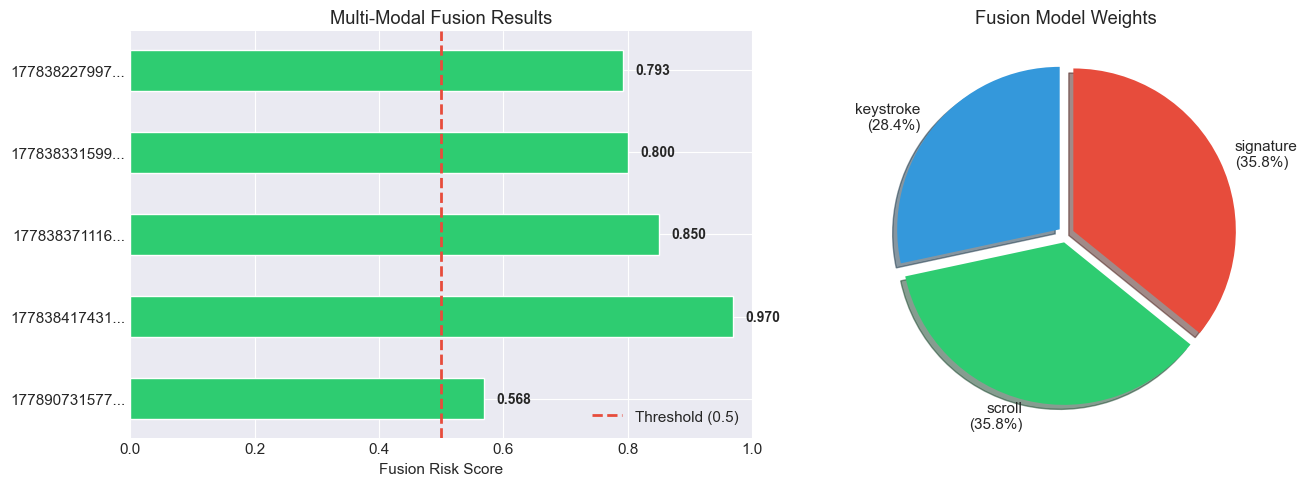

In [14]:
# Visualization: Fusion results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk score bar chart
session_labels = [r['session'][:12] + '...' for r in results]
risk_scores = [r['risk_score'] for r in results]
bar_colors = ['#2ecc71' if r['verdict'] == 'AUTHENTIC' else '#e74c3c' for r in results]

bars = axes[0].barh(session_labels, risk_scores, color=bar_colors, edgecolor='white', height=0.5)
axes[0].axvline(x=threshold, color='#e74c3c', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')
axes[0].set_xlabel('Fusion Risk Score')
axes[0].set_title('Multi-Modal Fusion Results')
axes[0].set_xlim(0, 1)
axes[0].legend()
axes[0].invert_yaxis()

# Add score labels
for bar, score in zip(bars, risk_scores):
    axes[0].text(score + 0.02, bar.get_y() + bar.get_height()/2, f'{score:.3f}', 
                va='center', fontsize=10, fontweight='bold')

# Model weights pie chart
w_labels = list(weights.keys())
w_values = list(weights.values())
pie_colors = ['#3498db', '#2ecc71', '#e74c3c']
explode = [0.05] * len(w_labels)

axes[1].pie(w_values, labels=[f'{l}\n({v:.1%})' for l, v in zip(w_labels, w_values)],
           colors=pie_colors[:len(w_labels)], explode=explode[:len(w_labels)],
           autopct='', startangle=90, shadow=True)
axes[1].set_title('Fusion Model Weights')

plt.tight_layout()
plt.show()

In [15]:
print('=' * 50)
print('MULTI-MODAL BIOMETRICS DEMO COMPLETE')
print('=' * 50)
print(f'\nModels trained: 3 sub-models + 1 fusion layer')
print(f'Total params : {keystroke_model.count_params() + signature_model.count_params():,}')
print(f'Model files  : {len(os.listdir(MODEL_DIR))} files in {MODEL_DIR}')

MULTI-MODAL BIOMETRICS DEMO COMPLETE

Models trained: 3 sub-models + 1 fusion layer
Total params : 54,137
Model files  : 9 files in g:\Kegiatan\Project\Digital Forensic\App\Multi Modal\models
